In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Data loading

coaster_db

In [2]:
df = pd.read_csv('coaster_db.csv')

In [4]:
df.tail()

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
1082,American Dreier Looping,"3,444 ft (1,050 m)",53 mph (85 km/h),Other,NaN,NaN,Steel,Anton Schwarzkopf,55 in (140 cm),NaN,...,53 mph,85 km/h,53.0,mph,53.0,111.0,ft,NaN,3,4.7
1083,Pantheon (roller coaster),"3,328 ft (1,014 m)",73 mph (117 km/h),Busch Gardens Williamsburg,Under construction,2022,Steel – Launched,Intamin,NaN,Blitz Coaster,...,73 mph,117 km/h,73.0,mph,73.0,178.0,ft,NaN,2,NaN
1084,Tron Lightcycle Power Run,"3,169.3 ft (966.0 m)",59.3[1] mph (95.4 km/h),Other,NaN,"June 16, 2016",Steel – Launched,Vekoma,4[2] ft (122 cm),Motorbike roller coaster,...,59.3 mph,95.4 km/h,59.3,mph,59.3,78.1,ft,NaN,0,4.0
1085,Tumbili,770 ft (230 m),34 mph (55 km/h),Kings Dominion,Under construction,NaN,Steel – 4th Dimension – Wing Coaster,S&S – Sansei Technologies,NaN,4D Free Spin,...,34 mph,55 km/h,34.0,mph,34.0,112.0,ft,NaN,0,NaN
1086,Wonder Woman Flight of Courage,"3,300 ft (1,000 m)",58 mph (93 km/h),Six Flags Magic Mountain,Under construction,2022,Steel – Single-rail,Rocky Mountain Construction,NaN,Raptor – Custom,...,58 mph,93 km/h,58.0,mph,58.0,131.0,ft,NaN,3,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 56 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   coaster_name                   1087 non-null   object 
 1   Length                         953 non-null    object 
 2   Speed                          937 non-null    object 
 3   Location                       1087 non-null   object 
 4   Status                         874 non-null    object 
 5   Opening date                   837 non-null    object 
 6   Type                           1087 non-null   object 
 7   Manufacturer                   1028 non-null   object 
 8   Height restriction             831 non-null    object 
 9   Model                          744 non-null    object 
 10  Height                         965 non-null    object 
 11  Inversions                     932 non-null    float64
 12  Lift/launch system             795 non-null    o

### Missing data volume

In [6]:
df.isna().sum()

,0
coaster_name,0
Length,134
Speed,150
Location,0
Status,213
Opening date,250
Type,0
Manufacturer,59
Height restriction,256
Model,343


### 1. Missing data - Unknown (Manufacturer)

In [7]:
df['Manufacturer'].value_counts()

,count
Manufacturer,
Vekoma,135
Bolliger & Mabillard,119
Intamin,99
Mack Rides,62
Arrow Dynamics,54
...,...
BHS,1
British Rail Engineering Limited,1
"Bailey Rides, Inc.",1


In [8]:
df['Manufacturer'] = df['Manufacturer'].fillna('Unknown')

### 2. Missing data - the most used (Status)

In [9]:
df['Status'].value_counts()

,count
Status,
Operating,668
Removed,137
Closed,24
Under construction,15
In Production,11
Discontinued,7
Closed in 2021,2
SBNO December 2019,2
Chapter 7 bankruptcy; rides dismantled and sold; property sold,2


In [11]:
df['Status'] = df['Status'].fillna(df['Status'].value_counts().index[0])

In [15]:
list_ = pd.Series(['Operating','Closed'])

In [20]:
list_.sample(weights=[0.7,0.3])

,0
1,Closed


### 3. Missing data - Mean (Inversions)

In [21]:
df['Inversions'].mean()

1.5472103004291846

In [28]:
df[df['Inversions'] > 3]['Inversions'].describe()

,Inversions
count,171.000000
mean,5.274854
std,1.363563
min,4.000000
25%,4.000000
50%,5.000000
75%,6.000000
max,14.000000


In [30]:
pd.cut(df['Inversions'], bins=4)

,Inversions
0,NaN
1,"(-0.014, 3.5]"
2,NaN
3,"(-0.014, 3.5]"
4,"(-0.014, 3.5]"
...,...
1082,"(-0.014, 3.5]"
1083,"(-0.014, 3.5]"
1084,"(-0.014, 3.5]"
1085,"(-0.014, 3.5]"


### 4. Missing data - Mean (Gforce-clean)

Outliars - boxplot

Fiiling in by mean without outliars

In [31]:
df['Gforce_clean'].describe()

,Gforce_clean
count,362.000000
mean,3.824006
std,0.989998
min,0.800000
25%,3.400000
50%,4.000000
75%,4.500000
max,12.000000


<Axes: ylabel='Gforce_clean'>

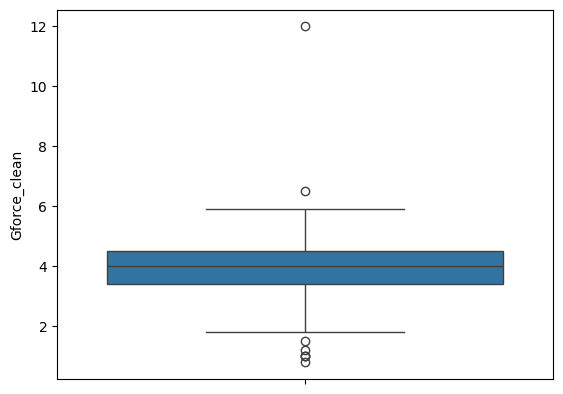

In [32]:
sns.boxplot(df['Gforce_clean'])

In [33]:
df[(df['Gforce_clean'] > 2) & (df['Gforce_clean'] < 6)]['Gforce_clean'].mean()

3.8614

### 5. Missing data - Ffill, Bfill (Speed1, Speed2)

In [36]:
df['speed1_value'].describe()

,speed1_value
count,937.000000
mean,53.850374
std,23.385518
min,5.000000
25%,40.000000
50%,50.000000
75%,63.000000
max,240.000000


In [37]:
df['speed1_value'].fillna(method='ffill')
df['speed1_value'].fillna(method='bfill')

,speed1_value
0,6.0
1,10.0
2,10.0
3,10.0
4,10.0
...,...
1082,53.0
1083,73.0
1084,59.3
1085,34.0


### 6. Simple Imputer

In [38]:
from sklearn.impute import SimpleImputer, KNNImputer

In [39]:
imputer = SimpleImputer(missing_values = np.nan,
                        strategy ='mean',
                        add_indicator=False)
data = np.array([[12, np.nan, 34],[10, 32, np.nan],
        [np.nan, 11, 20]])
data

array([[12., nan, 34.],
       [10., 32., nan],
       [nan, 11., 20.]])

In [40]:
imputer.fit(data)
data = imputer.transform(data)

In [41]:
data

array([[12. , 21.5, 34. ],
       [10. , 32. , 27. ],
       [11. , 11. , 20. ]])

In [ ]:
data = [[12, np.nan, 34], [10, 32, np.nan],
        [np.nan, 11, 20]]
data

### 7. KNN Imputer

In [48]:
dict = {'Maths':[80, 90, np.nan, 95],
        'Chemistry': [60, 65, 56, np.nan],
        'Physics':[np.nan, 57, 80, 78],
       'Biology' : [78,83,67,np.nan]}
df = pd.DataFrame(dict)
df

,Maths,Chemistry,Physics,Biology
0,80.0,60.0,NaN,78.0
1,90.0,65.0,57.0,83.0
2,NaN,56.0,80.0,67.0
3,95.0,NaN,78.0,NaN


In [49]:
imputer = KNNImputer()
After_imputation = imputer.fit_transform(df)

In [50]:
After_imputation

array([[80.        , 60.        , 71.66666667, 78.        ],
       [90.        , 65.        , 57.        , 83.        ],
       [88.33333333, 56.        , 80.        , 67.        ],
       [95.        , 60.33333333, 78.        , 76.        ]])

In [45]:
(80 + 90 + 95) / 3

88.33333333333333